In [1]:
# =======================
# 1. Imports & setup
# =======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# =======================
# 2. Load both datasets
# =======================
health_df = pd.read_csv("/content/Healthcare Demo Data.csv")
flu_df = pd.read_excel("/content/Flu shot 2019.xlsx")

print("Healthcare Demo Data shape:", health_df.shape)
print("Flu Shot 2019 shape:", flu_df.shape)

# =======================
# 3. Clean & feature-engineer Healthcare Demo Data
# =======================

# --- Parse encounter start time & get month ---
health_df["start_dt"] = pd.to_datetime(
    health_df["start"],
    format="%d-%m-%y %H:%M",
    errors="coerce"
)
health_df["month"] = health_df["start_dt"].dt.to_period("M").astype(str)

# --- Parse birthdate and create approximate age ---
# Dates are like "18-08-70". We interpret them as 1970 etc.
birth = pd.to_datetime(health_df["birthdate"], format="%d-%m-%y", errors="coerce")

# If year accidentally becomes > 2022 (e.g. 2059), shift back 100 years
birth = birth.mask(birth.dt.year > 2022, birth - pd.DateOffset(years=100))

health_df["age"] = 2022 - birth.dt.year
health_df.loc[health_df["age"] < 0, "age"] = np.nan  # drop weird negatives

# Create age bands
age_bins = [0, 18, 30, 45, 60, 75, 100]
age_labels = ["0-17", "18-29", "30-44", "45-59", "60-74", "75+"]

health_df["age_band"] = pd.cut(
    health_df["age"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

print("\nHealthcare columns:", health_df.columns.tolist())
print("\nSample rows:")
display(health_df.head())


Healthcare Demo Data shape: (21669, 24)
Flu Shot 2019 shape: (903, 11)

Healthcare columns: ['encounter_id', 'start', 'stop', 'encounterclass', 'enc_type', 'base_encounter_cost', 'total_claim_cost', 'organization', 'enc_reason', 'payer', 'payer_category', 'patient_id', 'first', 'last', 'birthdate', 'ethnicity', 'race', 'zip', 'flu_2022', 'covid', 'org_name', 'org_zip', 'org_city', 'org_state', 'start_dt', 'month', 'age', 'age_band']

Sample rows:


,encounter_id,start,stop,encounterclass,enc_type,base_encounter_cost,total_claim_cost,organization,enc_reason,payer,...,flu_2022,covid,org_name,org_zip,org_city,org_state,start_dt,month,age,age_band
0,b7176285-98e8-4b5a-b349-bad45cdf4a56,03-07-22 16:46,03-07-22 17:01,ambulatory,Hospital Encounter with Problem,85.55,8180.50,a5577e5c-b886-37a0-8eee-8ff6feb7ea6b,Malignant neoplasm of other specified sites of...,Medicare,...,1,1,MOUNT AUBURN HOSPITAL,21385502,CAMBRIDGE,MA,2022-07-03 16:46:00,2022-07,52.0,45-59
1,c1b2ad14-69c0-df4f-6f36-900f1eed28d0,05-08-22 10:46,05-08-22 11:01,ambulatory,Hospital Encounter with Problem,85.55,10825.52,a5577e5c-b886-37a0-8eee-8ff6feb7ea6b,Malignant neoplasm of other specified sites of...,Medicare,...,1,1,MOUNT AUBURN HOSPITAL,21385502,CAMBRIDGE,MA,2022-08-05 10:46:00,2022-08,52.0,45-59
2,cfd81d8d-1b1c-3394-639b-16f886d2896b,12-01-22 0:05,12-01-22 0:20,ambulatory,Hospital Encounter with Problem,85.55,85.55,a5577e5c-b886-37a0-8eee-8ff6feb7ea6b,Malignant neoplasm of other specified sites of...,Medicare,...,1,1,MOUNT AUBURN HOSPITAL,21385502,CAMBRIDGE,MA,2022-01-12 00:05:00,2022-01,52.0,45-59
3,e5e0521d-a0f8-0ea7-8f6f-8062f14ae011,27-03-22 12:46,27-03-22 13:01,ambulatory,Hospital Encounter with Problem,85.55,8018.49,a5577e5c-b886-37a0-8eee-8ff6feb7ea6b,Malignant neoplasm of other specified sites of...,Medicare,...,1,1,MOUNT AUBURN HOSPITAL,21385502,CAMBRIDGE,MA,2022-03-27 12:46:00,2022-03,52.0,45-59
4,d5a1fc26-992f-cb3b-5ab1-05a2ef4da0de,01-06-22 16:16,01-06-22 16:31,wellness,Issuance of a Death Certificate,136.80,211.38,764bf964-6ab7-30eb-885b-3d713ca43265,Malignant neoplasm of other specified sites of...,Medicare,...,0,0,OUTER CAPE HEALTH SERVICES,26677402,WELLFLEET,MA,2022-06-01 16:16:00,2022-06,63.0,60-74


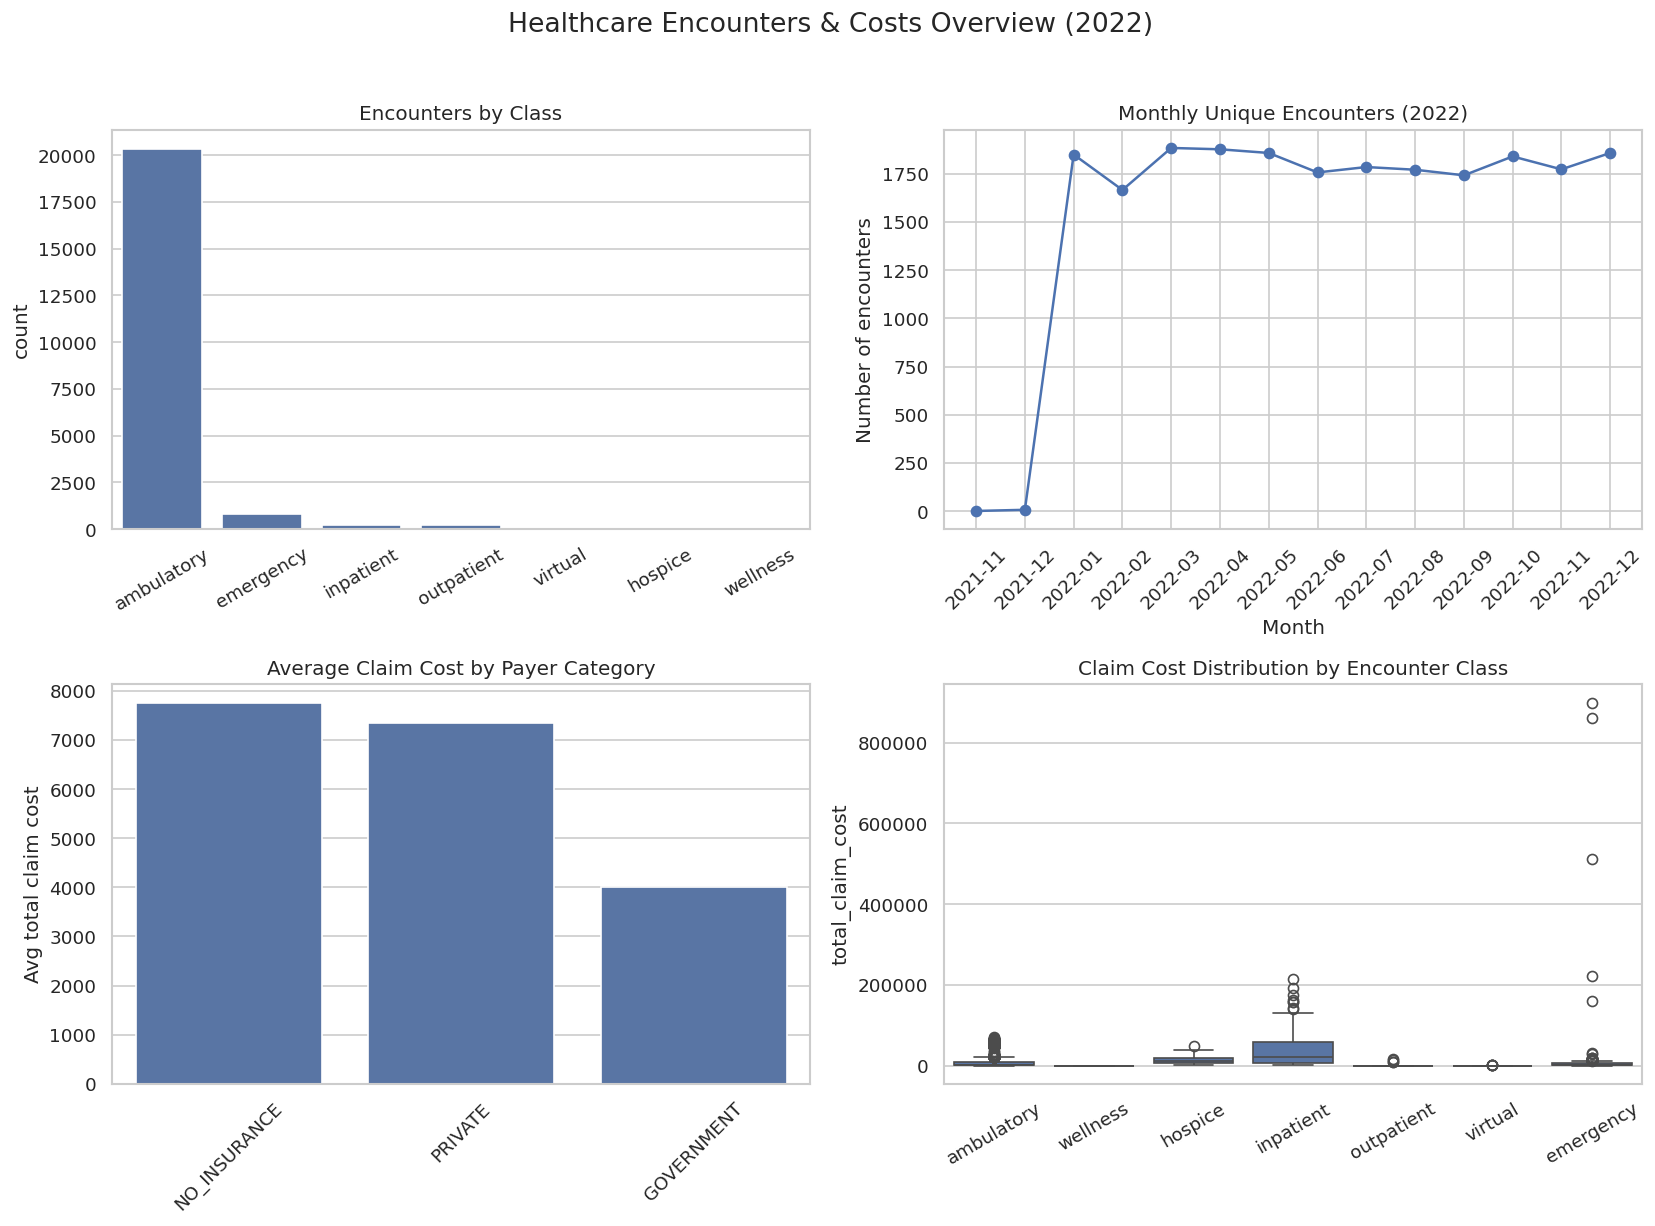

In [2]:
# =======================
# 4. Dashboard 1: Encounter & Cost Overview
# =======================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Healthcare Encounters & Costs Overview (2022)", fontsize=16, y=1.02)

# Top-left: Encounters by class
sns.countplot(
    data=health_df,
    x="encounterclass",
    order=health_df["encounterclass"].value_counts().index,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Encounters by Class")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", rotation=30)

# Top-right: Monthly unique encounters
monthly_counts = (
    health_df.groupby("month")["encounter_id"]
    .nunique()
    .reset_index(name="num_encounters")
    .sort_values("month")
)

axes[0, 1].plot(
    monthly_counts["month"],
    monthly_counts["num_encounters"],
    marker="o"
)
axes[0, 1].set_title("Monthly Unique Encounters (2022)")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Number of encounters")
axes[0, 1].tick_params(axis="x", rotation=45)

# Bottom-left: Average claim cost by payer category
payer_cost = (
    health_df.groupby("payer_category")["total_claim_cost"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=payer_cost,
    x="payer_category",
    y="total_claim_cost",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Average Claim Cost by Payer Category")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Avg total claim cost")
axes[1, 0].tick_params(axis="x", rotation=45)

# Bottom-right: Cost distribution by encounter class
sns.boxplot(
    data=health_df,
    x="encounterclass",
    y="total_claim_cost",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Claim Cost Distribution by Encounter Class")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Optional: save for LinkedIn
# fig.savefig("dashboard1_encounters_costs.png", dpi=300, bbox_inches="tight")


/tmp/ipython-input-932571576.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  health_df.groupby("age_band")["flu_2022"]


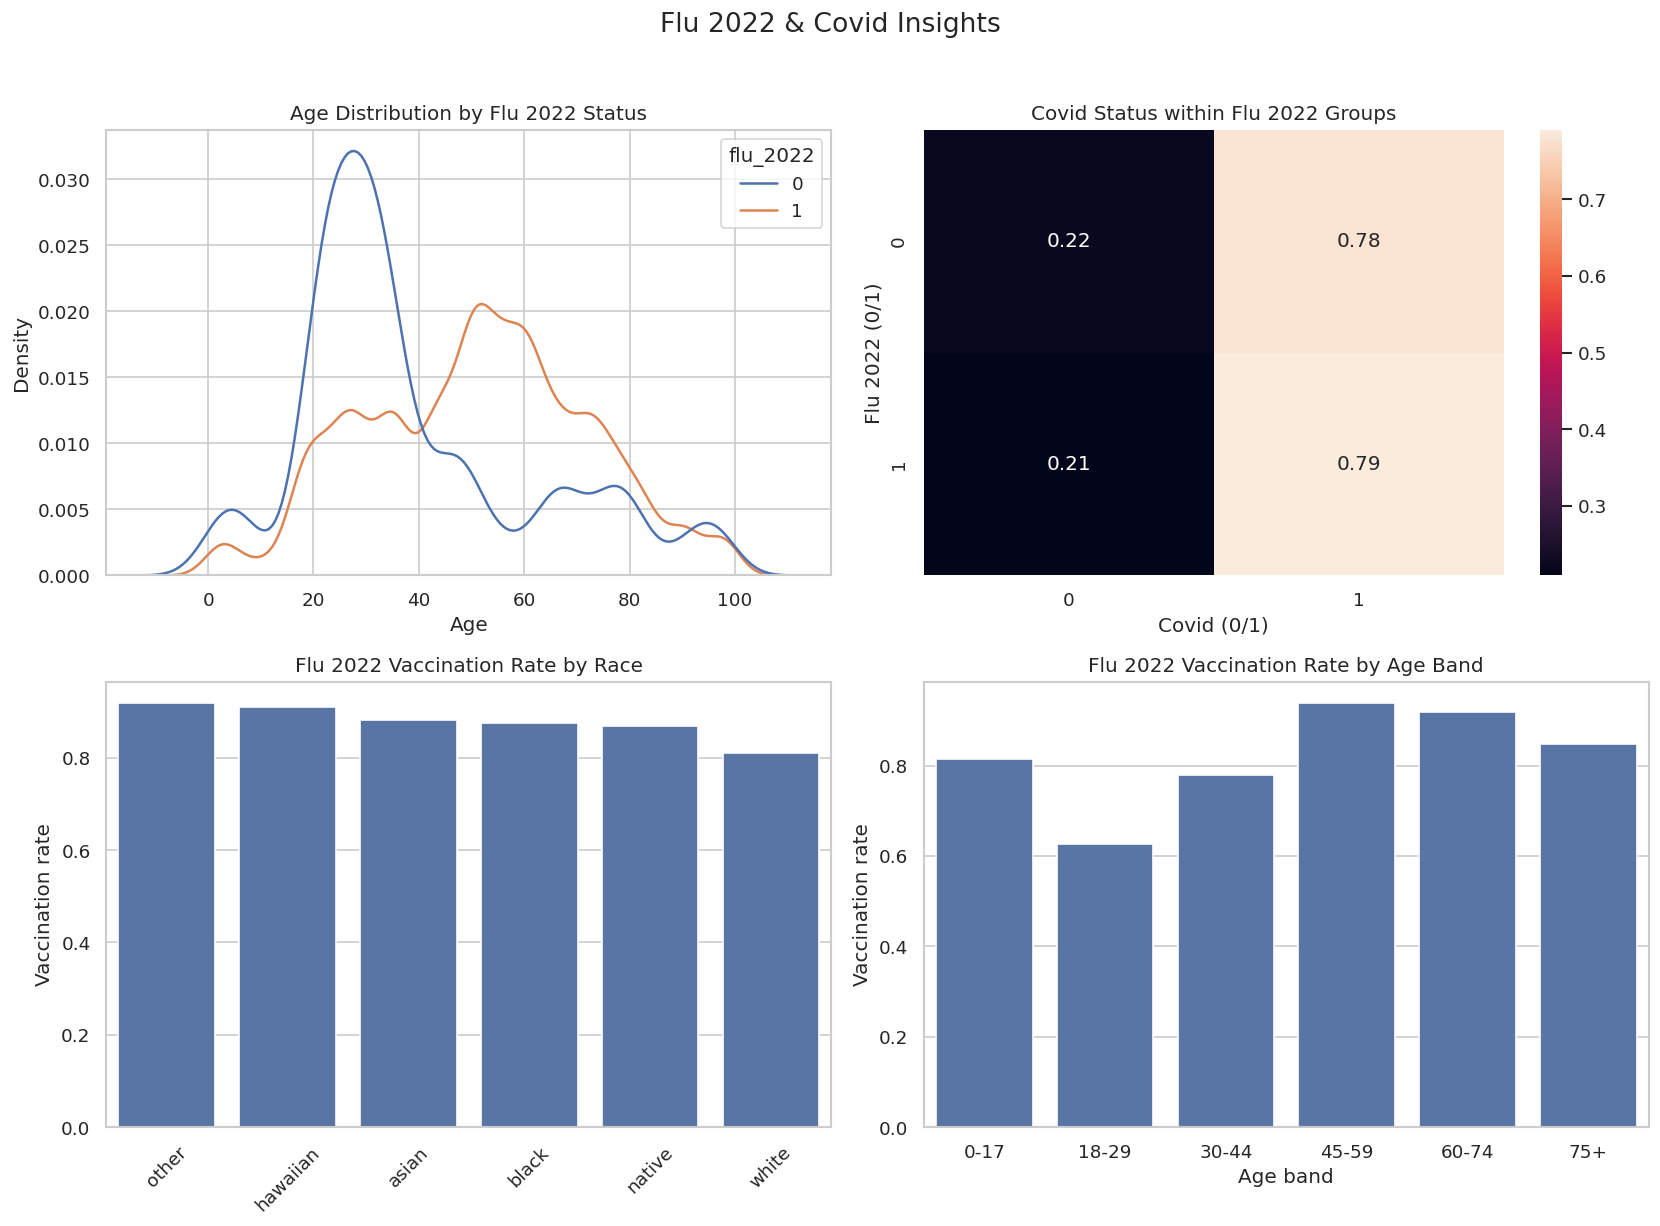

In [3]:
# =======================
# 5. Dashboard 2: Flu 2022 & Covid Insights
# =======================

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle("Flu 2022 & Covid Insights", fontsize=16, y=1.02)

# Top-left: Age distribution by flu_2022 status
sns.kdeplot(
    data=health_df.dropna(subset=["age"]),
    x="age",
    hue="flu_2022",
    common_norm=False,
    ax=axes2[0, 0]
)
axes2[0, 0].set_title("Age Distribution by Flu 2022 Status")
axes2[0, 0].set_xlabel("Age")

# Top-right: Heatmap of Covid status within flu_2022 groups
ct = pd.crosstab(health_df["flu_2022"], health_df["covid"], normalize="index")
sns.heatmap(
    ct,
    annot=True,
    fmt=".2f",
    ax=axes2[0, 1]
)
axes2[0, 1].set_title("Covid Status within Flu 2022 Groups")
axes2[0, 1].set_xlabel("Covid (0/1)")
axes2[0, 1].set_ylabel("Flu 2022 (0/1)")

# Bottom-left: Flu 2022 rate by race
flu_rate_race = (
    health_df.groupby("race")["flu_2022"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=flu_rate_race,
    x="race",
    y="flu_2022",
    ax=axes2[1, 0]
)
axes2[1, 0].set_title("Flu 2022 Vaccination Rate by Race")
axes2[1, 0].set_xlabel("")
axes2[1, 0].set_ylabel("Vaccination rate")
axes2[1, 0].tick_params(axis="x", rotation=45)

# Bottom-right: Flu 2022 rate by age band
flu_rate_age = (
    health_df.groupby("age_band")["flu_2022"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=flu_rate_age,
    x="age_band",
    y="flu_2022",
    ax=axes2[1, 1]
)
axes2[1, 1].set_title("Flu 2022 Vaccination Rate by Age Band")
axes2[1, 1].set_xlabel("Age band")
axes2[1, 1].set_ylabel("Vaccination rate")

plt.tight_layout()
plt.show()

# Optional:
# fig2.savefig("dashboard2_flu_covid.png", dpi=300, bbox_inches="tight")


Classification report:

              precision    recall  f1-score   support

           0       0.68      0.64      0.66       748
           1       0.93      0.94      0.93      3586

    accuracy                           0.89      4334
   macro avg       0.80      0.79      0.79      4334
weighted avg       0.88      0.89      0.88      4334

ROC AUC: 0.933


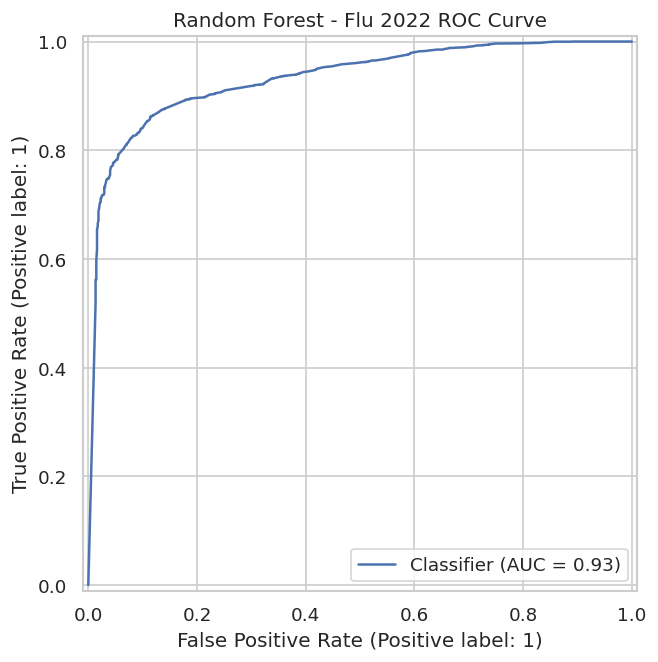

In [4]:
# =======================
# 6. Simple ML model: Predict Flu 2022 vaccination
# =======================

features = ["age", "race", "encounterclass", "payer_category", "covid"]
target = "flu_2022"

ml_df = health_df[features + [target]].dropna()

X = pd.get_dummies(ml_df[features], drop_first=True)
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Classification report:\n")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC: {roc_auc:.3f}")

# ROC curve
fig3, ax3 = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax3)
ax3.set_title("Random Forest - Flu 2022 ROC Curve")
plt.show()

# Optional:
# fig3.savefig("model_roc_curve.png", dpi=300, bbox_inches="tight")


/tmp/ipython-input-918308467.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flu_df.groupby("age_band")["shot_2019"]


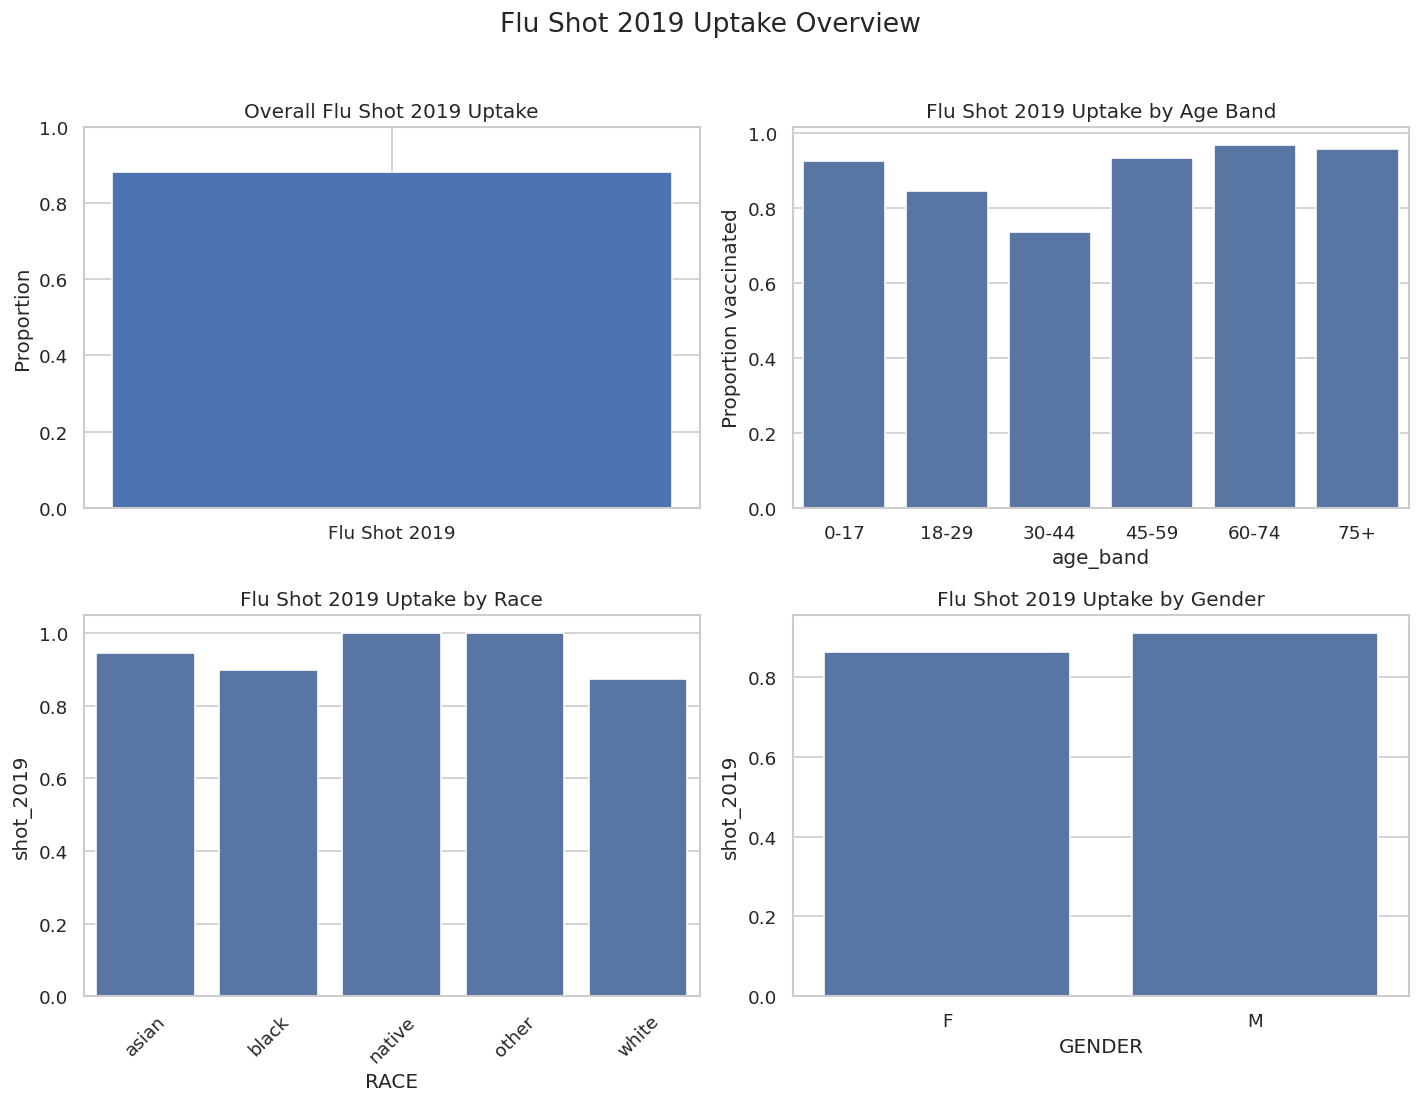

In [5]:
# =======================
# 7. Flu Shot 2019 Dashboard
# =======================

# Simple helper column
flu_df["shot_2019"] = flu_df["GET_FLU_SHOT_2019"]

# Age bands for this dataset too
flu_df["age_band"] = pd.cut(
    flu_df["AGE"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

fig4, axes4 = plt.subplots(2, 2, figsize=(12, 9))
fig4.suptitle("Flu Shot 2019 Uptake Overview", fontsize=16, y=1.02)

# Overall uptake
shot_rate = flu_df["shot_2019"].mean()
axes4[0, 0].bar(["Flu Shot 2019"], [shot_rate])
axes4[0, 0].set_ylim(0, 1)
axes4[0, 0].set_ylabel("Proportion")
axes4[0, 0].set_title("Overall Flu Shot 2019 Uptake")

# Age band uptake
age_rate = (
    flu_df.groupby("age_band")["shot_2019"]
    .mean()
    .reset_index()
)
sns.barplot(
    data=age_rate,
    x="age_band",
    y="shot_2019",
    ax=axes4[0, 1]
)
axes4[0, 1].set_title("Flu Shot 2019 Uptake by Age Band")
axes4[0, 1].set_ylabel("Proportion vaccinated")

# Race uptake
race_rate = (
    flu_df.groupby("RACE")["shot_2019"]
    .mean()
    .reset_index()
)
sns.barplot(
    data=race_rate,
    x="RACE",
    y="shot_2019",
    ax=axes4[1, 0]
)
axes4[1, 0].set_title("Flu Shot 2019 Uptake by Race")
axes4[1, 0].tick_params(axis="x", rotation=45)

# Gender uptake
gender_rate = (
    flu_df.groupby("GENDER")["shot_2019"]
    .mean()
    .reset_index()
)
sns.barplot(
    data=gender_rate,
    x="GENDER",
    y="shot_2019",
    ax=axes4[1, 1]
)
axes4[1, 1].set_title("Flu Shot 2019 Uptake by Gender")

plt.tight_layout()
plt.show()

# Optional:
# fig4.savefig("dashboard3_flu_2019.png", dpi=300, bbox_inches="tight")
